# Task 5: A real time series

The flights data contains a long-term increase and a repeating seasonal cycle.


In [6]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

DATA = Path("data")
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
GREY, QUIET = "#b8b8b8", "#cfceca"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e5e1", "axes.titleweight": "bold",
})

flights = pd.read_csv(DATA / "flights.csv")
month_names = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun", 7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}
flights["month_number"] = pd.to_datetime(flights["month"], format="%B").dt.month
flights["date"] = pd.to_datetime(flights["year"].astype(str) + "-" + flights["month_number"].astype(str) + "-01")
flights["month_name"] = flights["month_number"].map(month_names)
flights.head()

,year,month,passengers,month_number,date,month_name
0,1949,January,112,1,1949-01-01,Jan
1,1949,February,118,2,1949-02-01,Feb
2,1949,March,132,3,1949-03-01,Mar
3,1949,April,129,4,1949-04-01,Apr
4,1949,May,121,5,1949-05-01,May


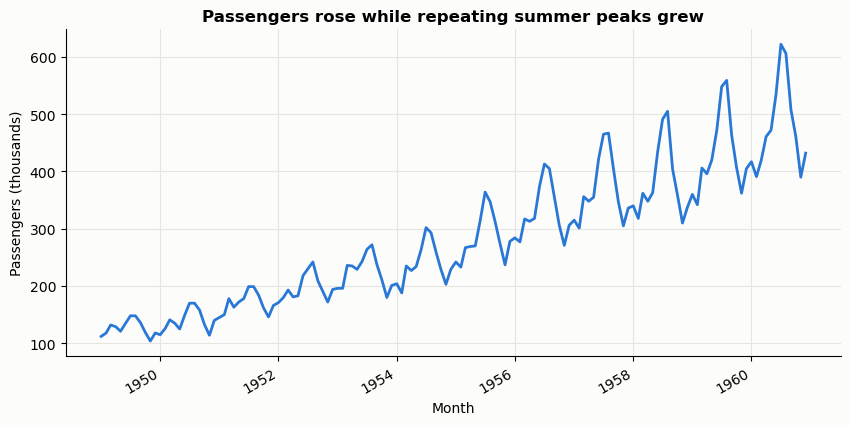

In [7]:
fig, ax = plt.subplots(figsize=(10, 4.8))
ax.plot(flights["date"], flights["passengers"], color=BLUE, linewidth=2)
ax.set_title("Passengers rose while repeating summer peaks grew"); ax.set_xlabel("Month"); ax.set_ylabel("Passengers (thousands)"); fig.autofmt_xdate(); plt.show()


### Chart 1: chart choice

A line chart is appropriate because the observations form an ordered monthly time series. Combining year and month into a real date preserves chronological order and reveals both the long-term rise and seasonal cycle.


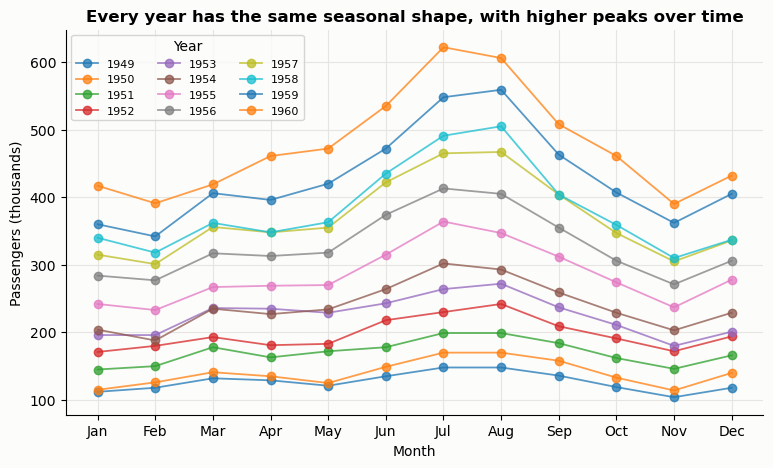

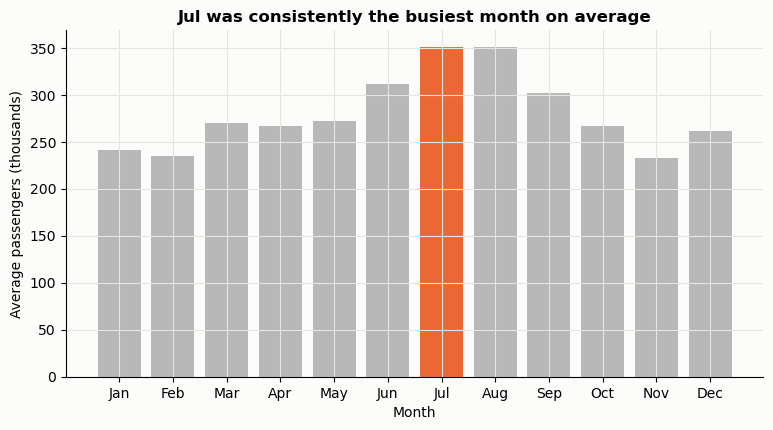

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
for year, group in flights.groupby("year"):
    ax.plot(group["month_number"], group["passengers"], marker="o", linewidth=1.3, alpha=0.75, label=str(year))
ax.set_title("Every year has the same seasonal shape, with higher peaks over time")
ax.set_xlabel("Month")
ax.set_ylabel("Passengers (thousands)")
ax.set_xticks(range(1, 13), [month_names[i] for i in range(1, 13)])
ax.legend(ncol=3, fontsize=8, title="Year")
plt.show()

monthly_means = (
    flights.groupby(["month_number", "month_name"], as_index=False)["passengers"]
    .mean()
    .sort_values("month_number")
)
busiest = monthly_means.loc[monthly_means["passengers"].idxmax(), "month_name"]
fig, ax = plt.subplots(figsize=(9, 4.5))
colours = [ORANGE if month == busiest else GREY for month in monthly_means["month_name"]]
ax.bar(monthly_means["month_name"], monthly_means["passengers"], color=colours)
ax.set_title(f"{busiest} was consistently the busiest month on average")
ax.set_xlabel("Month")
ax.set_ylabel("Average passengers (thousands)")
plt.show()

### Charts 2 and 3: choices

The yearly seasonal lines isolate the repeating within-year cycle while retaining year-to-year growth. The bar chart makes the consistently busiest month obvious and uses a zero baseline for comparison.


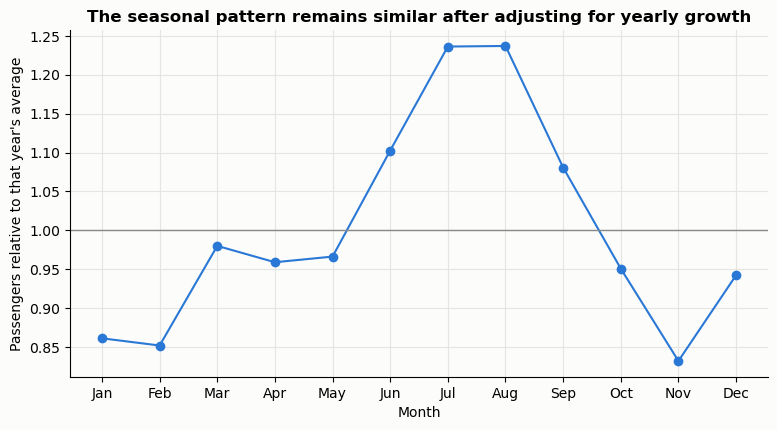

In [11]:
seasonal = flights.copy()
seasonal["relative_passengers"] = seasonal["passengers"] / seasonal.groupby("year")["passengers"].transform("mean")
normalised = seasonal.groupby("month_number", as_index=False)["relative_passengers"].mean()
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(normalised["month_number"], normalised["relative_passengers"], marker="o", color=BLUE)
ax.axhline(1, color="#888888", linewidth=1)
ax.set_title("The seasonal pattern remains similar after adjusting for yearly growth")
ax.set_xlabel("Month")
ax.set_ylabel("Passengers relative to that year's average")
ax.set_xticks(range(1, 13), [month_names[i] for i in range(1, 13)])
plt.show()

### Final conclusion

For a report, I would include the chronological line chart because it establishes the main time trend. The normalised chart is the best companion when the report needs to distinguish seasonality from growth. The raw seasonal lines and busiest-month bar answer useful follow-up questions, but all three should not appear together because they repeat information. The normalised chart suggests that much of the larger raw seasonal swing comes from the airline growing, rather than from seasonality changing dramatically.
